In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv("telecom_churn_data.csv")

# Data Cleaning: Clean empty spaces in TotalCharges and convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Print the first 5 rows and data info
print("--- First 5 Rows of the Dataset ---")
print(df.head())

print("\n--- General Information About Dataset ---")
print(df.info())

--- First 5 Rows of the Dataset ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV 

--- Churn Rate by Internet Service Type ---
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980

--- Churn Rate by Tech Support Service ---
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


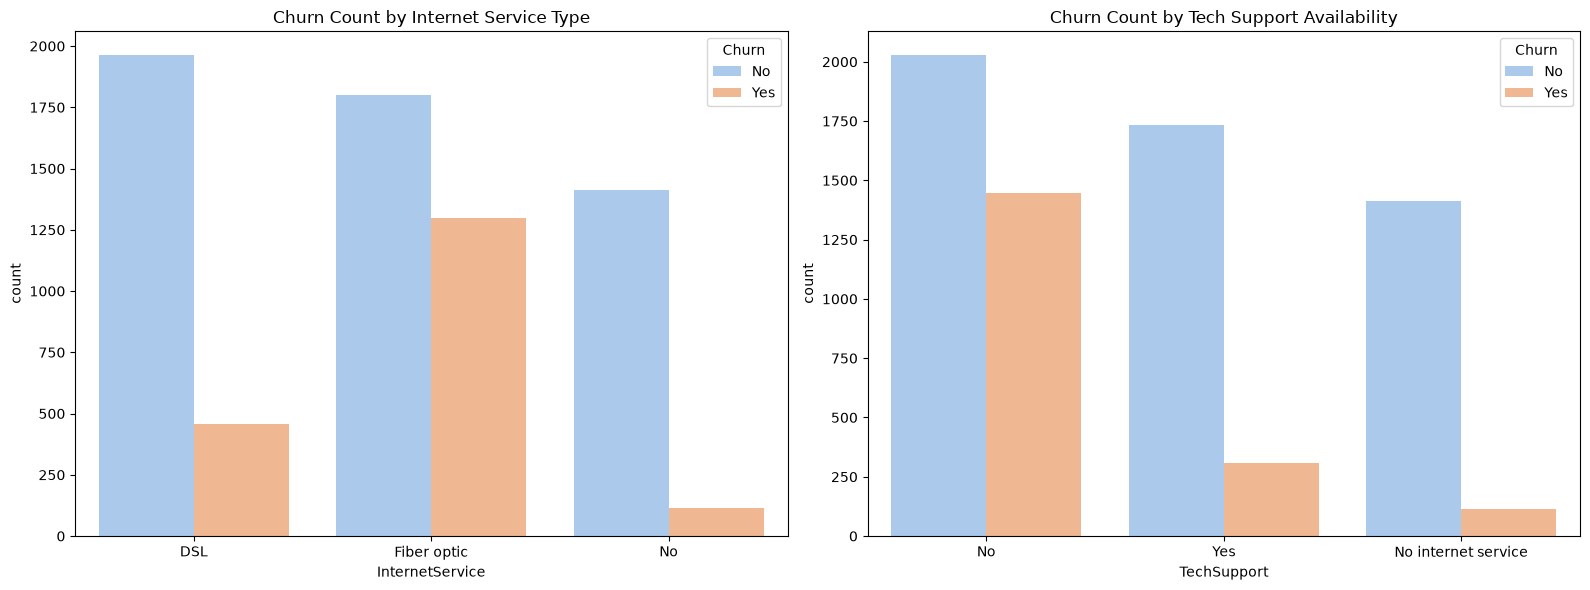

In [18]:
# Internet Service Type vs Churn Analysis
print("--- Churn Rate by Internet Service Type ---")
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
print(internet_churn)

# Tech Support vs Churn Analysis
print("\n--- Churn Rate by Tech Support Service ---")
tech_churn = pd.crosstab(df['TechSupport'], df['Churn'], normalize='index') * 100
print(tech_churn)

# Visualization: Interactive plots for Services
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Internet Service Plot
sns.countplot(data=df, x='InternetService', hue='Churn', ax=axes[0], palette='pastel')
axes[0].set_title('Churn Count by Internet Service Type')

# Tech Support Plot
sns.countplot(data=df, x='TechSupport', hue='Churn', ax=axes[1], palette='pastel')
axes[1].set_title('Churn Count by Tech Support Availability')

plt.tight_layout()
plt.show()

--- Average Monthly Charges by Churn ---
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

--- Average Tenure (Months) by Churn ---
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


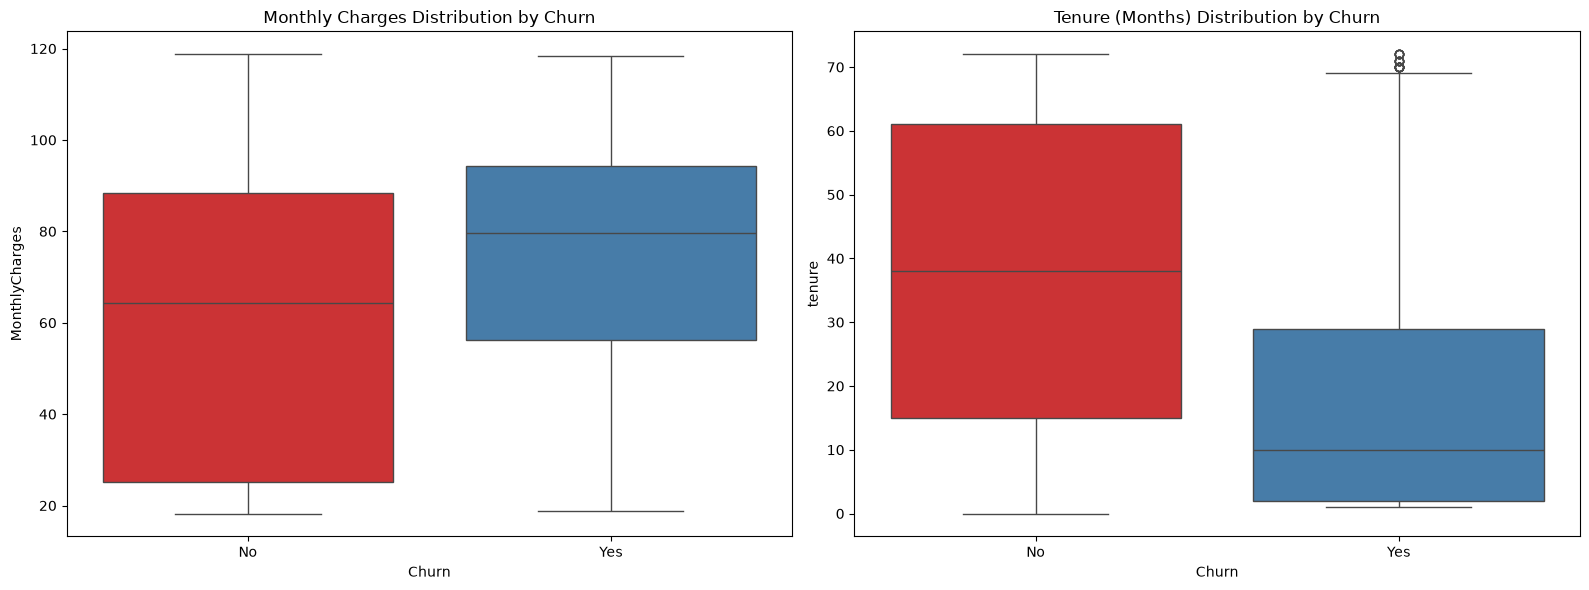

In [19]:
# Statistical Summary of Monthly Charges for Churn vs Retained Customers
print("--- Average Monthly Charges by Churn ---")
print(df.groupby('Churn')['MonthlyCharges'].mean())

# Statistical Summary of Tenure (Months in Company) by Churn
print("\n--- Average Tenure (Months) by Churn ---")
print(df.groupby('Churn')['tenure'].mean())

# Visualization: Boxplots to see the distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly Charges Distribution
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0], palette='Set1')
axes[0].set_title('Monthly Charges Distribution by Churn')

# Tenure Distribution
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1], palette='Set1')
axes[1].set_title('Tenure (Months) Distribution by Churn')

plt.tight_layout()
plt.show()

In [20]:
print("Identifying Risky VIP Customers")

# Filtering criteria based on our data insights

average_monthly_charge = df['MonthlyCharges'].mean()

vip_risk_group = df[
    (df['Contract'] == 'Month-to-month') & 
    (df['MonthlyCharges'] > average_monthly_charge) & 
    (df['tenure'] <= 18) &
    (df['Churn'] == 'No') # Active customers we can still save
]

print(f"Active High-Risk VIP Customers Needing Immediate Action: {len(vip_risk_group)}")
print("\n--- Top 10 High-Risk Customers (For Marketing/Retention Team) ---")
print(vip_risk_group[['customerID', 'tenure', 'Contract', 'MonthlyCharges', 'PaymentMethod']].head(10))

Identifying Risky VIP Customers
Active High-Risk VIP Customers Needing Immediate Action: 454

--- Top 10 High-Risk Customers (For Marketing/Retention Team) ---
     customerID  tenure        Contract  MonthlyCharges  \
31   4929-XIHVW       2  Month-to-month           95.50   
44   4080-IIARD      13  Month-to-month           76.20   
65   5122-CYFXA       3  Month-to-month           75.30   
69   7410-OIEDU      10  Month-to-month           79.85   
85   4445-ZJNMU       9  Month-to-month           99.30   
91   2424-WVHPL       1  Month-to-month           74.70   
115  3071-VBYPO       3  Month-to-month           89.85   
130  2876-GZYZC      13  Month-to-month           85.95   
149  3466-BYAVD      15  Month-to-month           69.50   
150  3780-YVMFA       8  Month-to-month           68.55   

               PaymentMethod  
31   Credit card (automatic)  
44          Electronic check  
65          Electronic check  
69              Mailed check  
85   Credit card (automatic)  
91  

Correlation Analysis


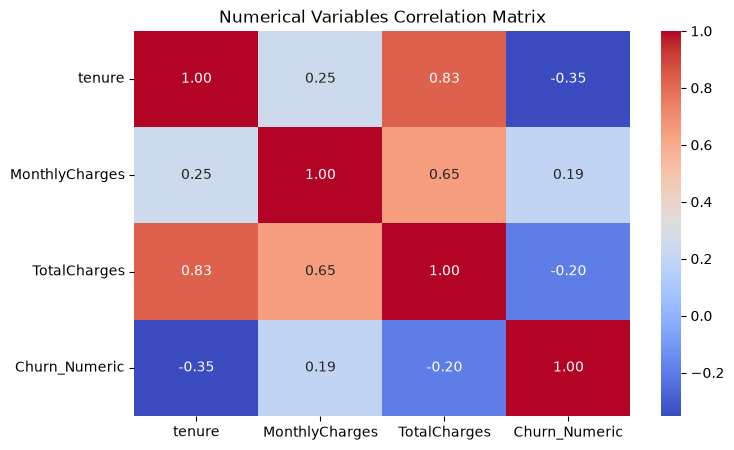

Correlation Insights:
- Negative (-) correlation between tenure and Churn confirms that longer customer lifetime reduces churn probability.
- Positive (+) correlation between MonthlyCharges and Churn proves that higher bills drive customers away.


In [21]:
print("Correlation Analysis")

# Convert Churn to numeric (Yes=1, No=0) to calculate numerical correlations
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 5))
correlation_matrix = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Numerical Variables Correlation Matrix')
plt.show()

print("Correlation Insights:")
print("- Negative (-) correlation between tenure and Churn confirms that longer customer lifetime reduces churn probability.")
print("- Positive (+) correlation between MonthlyCharges and Churn proves that higher bills drive customers away.")

In [22]:
print("Exporting Actionable Risk List to CSV")

# Exporting the list so the marketing or call center team can target these customers directly

vip_risk_group.to_csv("actionable_risk_customers.csv", index=False)
print("'actionable_risk_customers.csv' has been successfully saved to your project folder!")

Exporting Actionable Risk List to CSV
'actionable_risk_customers.csv' has been successfully saved to your project folder!
